In [1]:
import os
os.chdir('/kaggle/working')

!git clone https://github.com/basiaseweryn/generative-models-cat-images.git

Cloning into 'generative-models-cat-images'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 72 (delta 6), reused 12 (delta 3), pack-reused 54 (from 1)
Receiving objects: 100% (72/72), 224.91 MiB | 34.95 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Updating files: 100% (19/19), done.


In [28]:
%cd /kaggle/working/generative-models-cat-images

/kaggle/working/generative-models-cat-images


In [29]:
!git pull 

Already up to date.


In [31]:
import sys
import os
import os


PROJECT_ROOT = "/kaggle/working/generative-models-cat-images" 

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

UTILS_PATH = os.path.join(PROJECT_ROOT, "utils")
if UTILS_PATH not in sys.path:
    sys.path.insert(0, UTILS_PATH)

print(f"project root added: {PROJECT_ROOT}")
print(f"utils folder added: {UTILS_PATH}")
print(f"available files: {os.listdir(PROJECT_ROOT)}")

project root added: /kaggle/working/generative-models-cat-images
utils folder added: /kaggle/working/generative-models-cat-images/utils
available files: ['LICENSE', 'README.md', 'experiments.ipynb', 'requirements.txt', 'reports', '.gitignore', 'DL_project_3_plan.pdf', 'trained_models', '.git', 'outputs', 'utils', 'kaggle_analysis.ipynb']


In [30]:
import os
import sys
import torch
import pandas as pd

CATS_DATASET = "/kaggle/input/datasets/crawford/cat-dataset"
OUTPUT_DIR = "/kaggle/working/generative-models-cat-images/outputs"
PROJECT_DIR = "/kaggle/working/generative-models-cat-images"
FID_SAMPLES = 2000  

sys.path.insert(0, PROJECT_DIR)

import utils.config as cfg
cfg.DATA_DIR = CATS_DATASET
cfg.NUM_WORKERS = 0
cfg.OUTPUT_DIR = OUTPUT_DIR + "/"

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from utils.config import STAGE_1_SCENARIOS, STAGE_2_SCENARIOS, seed_everything
from utils.evaluation_utils import (
    compare_fid_scenarios,
    generate_candidate_grid,
    interpolate_between_latents,
    load_trained_model,
    save_interpolation_grid,
    save_latent_codes,
    save_sample_grid,
    show_image_grid,
)


def set_models_dir(results_dir):
    """Point utils at cloned repo checkpoints (works with GitHub evaluation_utils)."""
    import utils.evaluation_utils as ev
    path = results_dir.rstrip("/") + "/"
    cfg.TRAINED_MODELS_DIR = path
    ev.TRAINED_MODELS_DIR = path


def list_result_scenarios(results_dir):
    root = Path(results_dir)
    return sorted(p.name for p in root.iterdir() if p.is_dir() and (p / "model.pth").exists())


def list_sample_checkpoints(scenario, results_dir):
    paths = sorted(
        (Path(results_dir) / scenario).glob("samples_epoch_*.png"),
        key=lambda p: int(p.stem.split("_")[-1]),
    )
    return [str(p) for p in paths]


def show_checkpoint_progression(scenario, results_dir):
    paths = list_sample_checkpoints(scenario, results_dir)
    if not paths:
        print("No sample PNGs for", scenario)
        return
    fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p))
        ax.set_title(Path(p).name.replace(".png", ""))
        ax.axis("off")
    fig.suptitle(f"Training progression — {scenario}")
    plt.tight_layout()
    plt.show()


def show_saved_image(path, title=""):
    plt.figure(figsize=(10, 10))
    plt.imshow(Image.open(path))
    plt.title(title)
    plt.axis("off")
    plt.show()


def compute_fid_report(names, device, results_dir, max_samples, output_csv, label):
    available = [s for s in names if (Path(results_dir) / s / "model.pth").exists()]
    if not available:
        print(f"[{label}] no checkpoints found")
        return []
    print(f"[{label}] Computing FID:", available)
    set_models_dir(results_dir)
    return compare_fid_scenarios(
        available, device, max_samples=max_samples, save_csv=output_csv,
    )


def find_models_dir(project_dir):
    """Folder with stage_*/model.pth (handles trained_models/trained_models/ nesting)."""
    base = os.path.join(project_dir, "trained_models")
    for candidate in [base, os.path.join(base, "trained_models")]:
        if list_result_scenarios(candidate):
            return candidate
    return base


MODELS_DIR = find_models_dir(PROJECT_DIR)
set_models_dir(MODELS_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything()
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/stage_3", exist_ok=True)

print("Device:", device)
print("Cats data:", CATS_DATASET, "exists:", os.path.isdir(CATS_DATASET))
print("Models dir:", MODELS_DIR)
print("Checkpoints:", list_result_scenarios(MODELS_DIR))

Random seed set to 42
Device: cuda
Cats data: /kaggle/input/datasets/crawford/cat-dataset exists: True
Models dir: /kaggle/working/generative-models-cat-images/trained_models
Checkpoints: ['stage_1_dcgan', 'stage_1_vae', 'stage_2_dcgan_batch_64', 'stage_2_dcgan_lr_1e-4', 'stage_2_vae_latent_64', 'stage_2_vae_lr_1e-4']


## Stage 1 — Baseline (VAE vs DCGAN)

- Training sample grids (every 10 epochs)  
- **FID** — lower is better  
- Final samples at epoch 50

In [19]:
#already run, don't run again!

fid_stage1 = compute_fid_report(
    STAGE_1_SCENARIOS,
    device,
    results_dir=MODELS_DIR,
    max_samples=FID_SAMPLES,
    output_csv=f"{OUTPUT_DIR}/reports/fid_stage1.csv",
    label="stage_1",
)

[stage_1] Computing FID: ['stage_1_vae', 'stage_1_dcgan']
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 214MB/s] 


FID [stage_1_vae] (2000 samples): 196.90
FID [stage_1_dcgan] (2000 samples): 146.08
Saved FID table -> /kaggle/working/generative-models-cat-images/outputs/reports/fid_stage1.csv


In [9]:
fid_stage1 = pd.read_csv("/kaggle/working/generative-models-cat-images/reports/fid_stage1.csv")
print(fid_stage1)
#the stage_1_dcgan achieved lower FID => baseline DCGAN is better than baseline VAE

        scenario  model  stage      lr  latent_dim  batch_size  subset_ratio  \
0    stage_1_vae    vae      1  0.0010         128         128           1.0   
1  stage_1_dcgan  dcgan      1  0.0002         128         128           1.0   

      fid  
0  196.90  
1  146.08  


## Stage 2 — Hyperparameters

These runs used **25% of the data** (`subset_ratio=0.25`). Compare FID **within stage 2** only.  
For interpolation (stage 3), prefer **stage 1** models (full data, 50 epochs) unless you retrained the winner on 100% data.

In [32]:
fid_stage2 = []
fid_stage2 = compute_fid_report(
    STAGE_2_SCENARIOS,
    device,
    results_dir=MODELS_DIR,
    max_samples=FID_SAMPLES,
    output_csv=f"{PROJECT_DIR}/reports/fid_stage2_hyperparams.csv",
    label="stage_2", 
)

[stage_2] Computing FID: ['stage_2_vae_lr_1e-4', 'stage_2_vae_latent_64', 'stage_2_dcgan_lr_1e-4', 'stage_2_dcgan_batch_64']
Using subset: 4998 / 19994 images (25%)
FID [stage_2_vae_lr_1e-4] (2000 samples): 248.06
Using subset: 4998 / 19994 images (25%)
FID [stage_2_vae_latent_64] (2000 samples): 194.86
Using subset: 4998 / 19994 images (25%)
FID [stage_2_dcgan_lr_1e-4] (2000 samples): 221.99
Using subset: 4998 / 19994 images (25%)
FID [stage_2_dcgan_batch_64] (2000 samples): 202.95
Saved FID table -> /kaggle/working/generative-models-cat-images/reports/fid_stage2_hyperparams.csv


In [33]:
fid_stage2 = pd.read_csv("/kaggle/working/generative-models-cat-images/reports/fid_stage2_hyperparams.csv")
print(fid_stage2)

                 scenario  model  stage      lr  latent_dim  batch_size  \
0     stage_2_vae_lr_1e-4    vae      2  0.0001         128          64   
1   stage_2_vae_latent_64    vae      2  0.0010          64          64   
2   stage_2_dcgan_lr_1e-4  dcgan      2  0.0001         128          64   
3  stage_2_dcgan_batch_64  dcgan      2  0.0002         128          64   

   subset_ratio     fid  
0          0.25  248.06  
1          0.25  194.86  
2          0.25  221.99  
3          0.25  202.95  


#### 'stage_1_dcgan' achieved the lowest FID. 

## Stage 3 — Latent interpolation (10 images)

1. Run the grid cell and **pick two image indices**  
2. Set `IDX_A` and `IDX_B` in the next cell  
3. You get **2 endpoints + 8 intermediate** generations (linear interpolation in latent space)

For the report: comment on whether the transition is smooth (structured latent space).

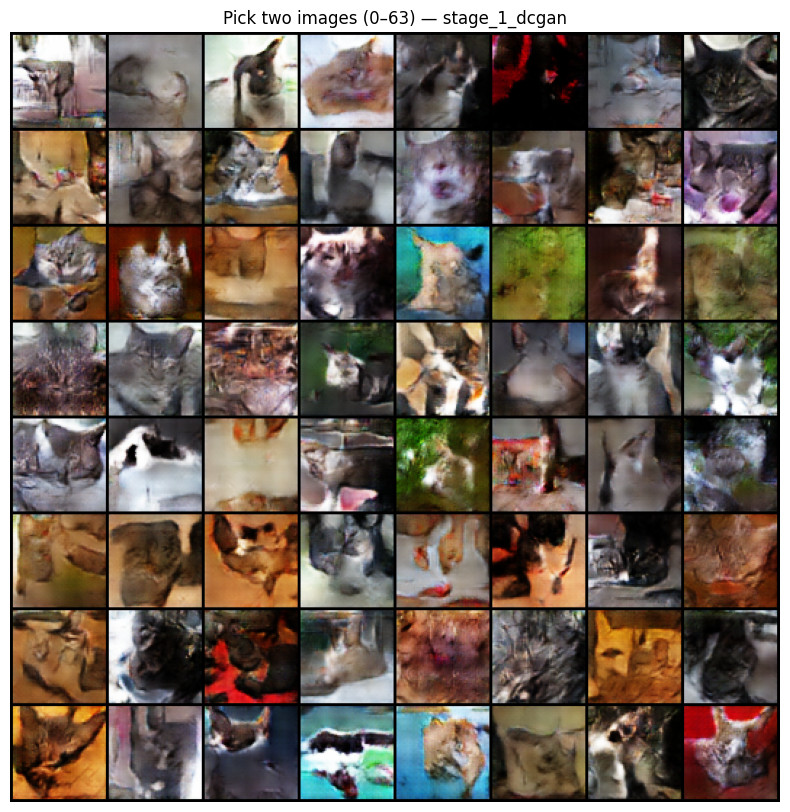

Saved grid -> /kaggle/working/generative-models-cat-images/outputs/stage_3/stage_1_dcgan_candidate_grid.png


In [34]:
SCENARIO = "stage_1_dcgan"

model, config, _ = load_trained_model(SCENARIO, device)
display_imgs, latents, _ = generate_candidate_grid(
    model, config, device, num_candidates=64, seed=123
)
show_image_grid(display_imgs, title=f"Pick two images (0–63) — {SCENARIO}", nrow=8)
save_sample_grid(
    display_imgs,
    f"{OUTPUT_DIR}/stage_3/{SCENARIO}_candidate_grid.png",
    nrow=8,
)

In [35]:
# i am choosing 2 visibly different pictures from the above candidate grid
IDX_A = 7
IDX_B = 16

z_a = latents[IDX_A].clone()
z_b = latents[IDX_B].clone()

latent_path = f"{OUTPUT_DIR}/stage_3/{SCENARIO}_interpolation_latents.pth"
save_latent_codes(z_a, z_b, latent_path)
print("Saved latent vectors:", latent_path)
print("z shape:", z_a.shape)

Saved latent codes -> /kaggle/working/generative-models-cat-images/outputs/stage_3/stage_1_dcgan_interpolation_latents.pth
Saved latent vectors: /kaggle/working/generative-models-cat-images/outputs/stage_3/stage_1_dcgan_interpolation_latents.pth
z shape: torch.Size([128])


Saved grid -> /kaggle/working/generative-models-cat-images/outputs/stage_3/stage_1_dcgan_interpolation_10.png


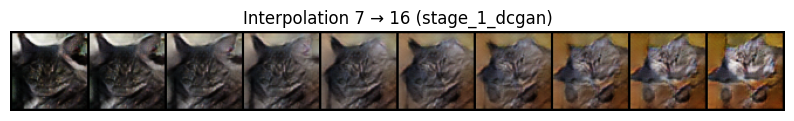

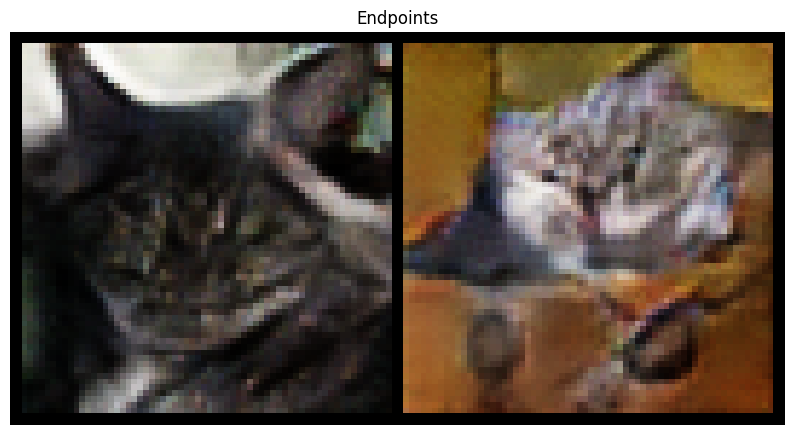

In [36]:
interp_display, interp_raw, is_dcgan = interpolate_between_latents(
    model, config, z_a, z_b, device, num_steps=8
)

interp_path = f"{OUTPUT_DIR}/stage_3/{SCENARIO}_interpolation_10.png"
save_interpolation_grid(interp_raw, interp_path, is_dcgan=is_dcgan)
show_image_grid(
    interp_display,
    title=f"Interpolation {IDX_A} → {IDX_B} ({SCENARIO})",
    nrow=10,
)

# Endpoints only (the two selected generations)
endpoints = torch.stack([interp_display[0], interp_display[-1]])
show_image_grid(endpoints, title="Endpoints", nrow=2)

## Download results

Click **Save Version**, then download from **Output**:

| File | Description |
|------|-------------|
| `outputs/reports/fid_stage1.csv` | VAE vs DCGAN FID |
| `outputs/reports/fid_stage2_hyperparams.csv` | Hyperparameter comparison |
| `outputs/stage_3/*` | Interpolation PNG + `.pth` latents |

In [ ]:
!find {OUTPUT_DIR} -type f | head -30